#### Objective
Build a baseline **Logistic Regression** model to predict **whether a trip would have a congestion fee** 
(`has_congestion_fee`) for NYC yellow taxi trips in January 2025 (post-congestion pricing).

In [16]:
# import libraries

# data handling
import pandas as pd
import numpy as np

# model
from sklearn.linear_model import LogisticRegression

# train/test split (if not already done)
from sklearn.model_selection import train_test_split

# scaling data
from sklearn.preprocessing import StandardScaler

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# optional: ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [17]:
# load engineered data
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
data.head()
#data.columns

,VendorID,tpep_pickup_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,is_extreme_fare,store_and_fwd_encoded,payment_name,ratecode_name,hour_x_dayofweek,time_slot,cbd_fee_ratio,total_surcharges,surcharges_ratio,base_fare_ratio
0,2,2025-01-05 00:00:02,1.0,8.66,1.0,138,43,1,35.200001,6.0,...,0,0,credit,standard,0,144,0.0,16.190001,25.202366,54.794521
1,2,2025-01-05 00:24:51,1.0,9.73,1.0,138,61,1,40.799999,6.0,...,0,0,credit,standard,0,144,0.0,9.250000,15.401265,67.932068
2,2,2025-01-05 00:54:12,1.0,10.33,1.0,138,62,1,41.500000,6.0,...,0,0,credit,standard,0,144,0.0,9.250000,15.226337,68.312759
3,2,2025-01-05 00:10:19,1.0,1.71,1.0,239,24,1,9.300000,1.0,...,0,0,credit,standard,0,144,0.0,5.000000,29.137529,54.195805
4,2,2025-01-05 00:29:32,1.0,1.80,1.0,236,143,1,10.700000,1.0,...,0,0,credit,standard,0,144,0.0,5.000000,26.539278,56.794056


In [18]:
# take 100,000 rows (adjust if needed)
data = data.sample(n=100_000, random_state=42)

print("Sampled dataset shape:", data.shape)

Sampled dataset shape: (100000, 45)


In [19]:
# drop unnecessary columns 
drop_cols = [
    # TARGETS
    "trip_duration_min",
    "has_congestion_fee",
    
    # RAW TIMESTAMP (time features already extracted)
    "tpep_pickup_datetime",
    
    # POST-TRIP FINANCIAL DATA
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    
    # LEAKY DERIVED FEATURES
    "avg_speed_mph",           # uses trip_duration_min in calculation
    "tip_to_total_ratio",      # post-trip
    "is_extreme_fare",         # based on fare_amount
    "cbd_fee_ratio",           # based on cbd_congestion_fee
    "total_surcharges",        # sum of post-trip surcharges
    "surcharges_ratio",        # post-trip ratio
    "base_fare_ratio",         # post-trip ratio
    
    # NOT PREDICTIVE FOR DURATION
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
]

existing_drop = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drop)
y = data["has_congestion_fee"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (100000, 22)


In [20]:
# encode categorical features
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Convert category dtype to string FIRST, then fill NaN
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  ✅ {col}: {len(le.classes_)} unique values → encoded")

/tmp/ipykernel_9881/435916135.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


Categorical columns: ['time_of_day', 'pickup_borough', 'dropoff_borough', 'distance_category', 'payment_name', 'ratecode_name']

  ✅ time_of_day: 4 unique values → encoded
  ✅ pickup_borough: 6 unique values → encoded
  ✅ dropoff_borough: 7 unique values → encoded
  ✅ distance_category: 3 unique values → encoded
  ✅ payment_name: 4 unique values → encoded
  ✅ ratecode_name: 5 unique values → encoded


In [22]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# create and fit logistic regression
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [26]:
from sklearn.metrics import classification_report
# evaluate model
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.66875
AUC: 0.7343551215635686
Confusion Matrix:
 [[3491 1627]
 [4998 9884]]
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.68      0.51      5118
           1       0.86      0.66      0.75     14882

    accuracy                           0.67     20000
   macro avg       0.63      0.67      0.63     20000
weighted avg       0.74      0.67      0.69     20000



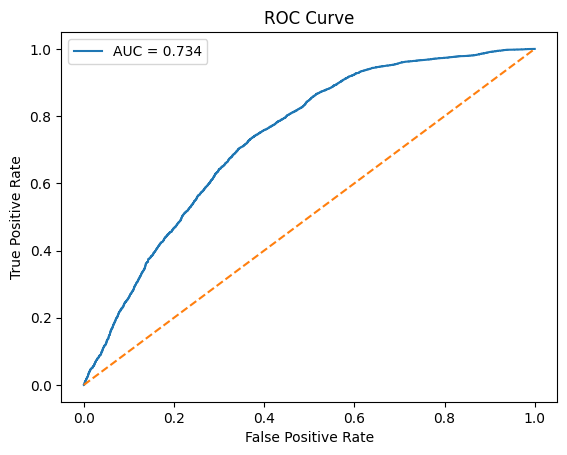

In [27]:
from sklearn.metrics import auc

# get probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# compute AUC
roc_auc = auc(fpr, tpr)

# plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()